In [1]:
import pandas as pd
import numpy as np
data_train = pd.read_csv("train.csv") # read data
n = data_train.shape[0]
print(n)

800


In [2]:
topic_ls = ", ".join(data_train["stat_category"].drop_duplicates())
topic_ls

'stat.ME, stat.ML, stat.TH, stat.AP, stat.CO'

# Data Generation

In [3]:
import time
import random
import concurrent.futures
import re
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import openai
from openai import OpenAI

client = OpenAI(api_key="...")

class RateLimitException(Exception):
    pass

@retry(
    retry=retry_if_exception_type(RateLimitException),
    wait=wait_exponential(multiplier=1, min=1, max=60),
    stop=stop_after_attempt(15)
)
def call_openai_api(client, prompt, n=20):
    try:
        response = client.chat.completions.create(
            model="gpt-4.1-nano",
            messages=[{"role": "user", "content": prompt}],
            n=n,
            temperature=1.5
        )
        return response
    except Exception as e:
        error_message = str(e).lower()
        if "rate limit" in error_message or "429" in error_message:
            wait_time_match = re.search(r'try again in (\d+)ms', error_message)
            if wait_time_match:
                wait_ms = int(wait_time_match.group(1))
                wait_time = (wait_ms / 1000) + random.uniform(0.1, 0.5)
            else:
                wait_time = random.uniform(1, 3)

            print(f"Rate limit hit. Waiting for {wait_time:.2f} seconds before retry...")
            time.sleep(wait_time)
            raise RateLimitException("Rate limit exceeded")
        else:
            raise

import re

def count_sentences(text: str) -> list[str]:
    """
    Split text into sentences conservatively.
    Returns a list of non-empty sentences.
    """
    # Split on ., ?, ! followed by space/newline or end of string
    parts = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9(])|(?<=[.!?])$', text.strip())
    # Clean up stray empties/whitespace
    sents = [s.strip() for s in parts if s and s.strip()]
    return sents

def process_item(client, idx, sentences):
    abstract = sentences[0]
    base_prompt = (
        "You are given a statistical abstract.\n\n"
        f"Abstract: {abstract}\n\n"
        "Task: Extend the abstract with additional details that remain consistent with the SAME statistical topic.\n"
        "- Write EXACTLY 6 sentences.\n"
        "- Do not copy wording from the original; paraphrase and add plausible extensions consistent with the same subject.\n"
        "- Avoid lists, bullets, headings, or numbering; just 6 full sentences in a single paragraph.\n"
        "- No disclaimers, no citations, no markdown.\n"
    )

    max_attempts = 20
    while max_attempts > 0:
        try:
            response = call_openai_api(client, base_prompt, n=1)
            content = response.choices[0].message.content.strip()
            sents = count_sentences(content)

            if len(sents) == 6:
                # Return clean paragraph
                return sents
            else:
                # Not exactly 10 → retry
                max_attempts -= 1
        except Exception:
            max_attempts -= 1

    print(f"Warning: Could not get exactly 6 sentences for item {idx}")
    return None

def process_with_rate_limiting(client, input_texts, max_concurrent=5, batch_size=20):
    all_responses = []

    for batch_start in range(0, len(input_texts), batch_size):
        batch_end = min(batch_start + batch_size, len(input_texts))
        batch = input_texts[batch_start:batch_end]

        print(f"Processing batch {batch_start // batch_size + 1}, items {batch_start} to {batch_end - 1}")

        with concurrent.futures.ThreadPoolExecutor(max_workers=max_concurrent) as executor:
            futures = [
                executor.submit(process_item, client, idx + batch_start, sentences)
                for idx, sentences in enumerate(batch)
            ]

            # Ensure order of responses matches order of input_texts
            batch_results = [future.result() for future in futures]

        all_responses.extend(batch_results)

        if batch_end < len(input_texts):
            wait_time = random.uniform(1, 3)
            time.sleep(wait_time)

    return all_responses

In [4]:
pairs = []
for i in range(data_train.shape[0]):
    pairs.append((data_train["abstract"].iloc[i], data_train["stat_category"].iloc[i]))

In [7]:
generations = process_with_rate_limiting(client, pairs)


Processing batch 1, items 0 to 19
Processing batch 2, items 20 to 39
Processing batch 3, items 40 to 59
Processing batch 4, items 60 to 79
Processing batch 5, items 80 to 99
Processing batch 6, items 100 to 119
Processing batch 7, items 120 to 139
Processing batch 8, items 140 to 159
Processing batch 9, items 160 to 179
Processing batch 10, items 180 to 199
Processing batch 11, items 200 to 219
Processing batch 12, items 220 to 239
Processing batch 13, items 240 to 259
Processing batch 14, items 260 to 279
Processing batch 15, items 280 to 299
Processing batch 16, items 300 to 319
Processing batch 17, items 320 to 339
Processing batch 18, items 340 to 359
Processing batch 19, items 360 to 379
Processing batch 20, items 380 to 399
Processing batch 21, items 400 to 419
Processing batch 22, items 420 to 439
Processing batch 23, items 440 to 459
Processing batch 24, items 460 to 479
Processing batch 25, items 480 to 499
Processing batch 26, items 500 to 519
Processing batch 27, items 520 t

In [8]:
import pickle

with open("generations_abstract.pickle", "wb") as file:
    pickle.dump(generations, file)

Gemini as Judge

In [5]:
import google.generativeai as genai
import os
import time
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

model = genai.GenerativeModel("gemini-2.5-flash")

def batch_eval(all_pairs, disease_ls, batch_size=20, max_retries=5, sleep_time=2, save_every=25, save_path="scores_checkpoint.csv"):
    all_scores = []
    batch_counter = 0  # track how many batches processed

    for start in range(0, all_pairs.shape[0], batch_size):
        end = min(start + batch_size, all_pairs.shape[0])
        batch = all_pairs.iloc[start:end]

        # Build base prompt
# Build base prompt
        prompt = (
            "You are evaluating individual sentences from extended statistical abstracts.\n\n"
            "Scoring instructions:\n"
            "- Assign each sentence a score between 0 and 1, rounded to two decimal places.\n"
            "- Criteria: The sentence should plausibly match the specified topic, remain coherent, and avoid drifting into other topics from the list.\n"
            "- Use the full 0–1 range: 1 = perfectly clear, on-topic, and informative; 0 = completely unusable.\n"
            "- 0.5 is the threshold: any sentence with a score ≤ 0.5 should be dropped to prevent topic drift.\n\n"
            "Output requirements:\n"
            "- Output only the scores, one per line, in the same order as the input cases.\n"
            "- Do not include explanations, text, or formatting other than the numeric scores.\n\n"
        )

        for i, row in batch.iterrows():
            sent, topic = row["abstract"], row["stat_category"]
            prompt += f"Case {i}:\nTopic: {topic}\nSentence: {sent}\n"

        # Retry loop
        scores = []
        for attempt in range(1, max_retries + 1):
            try:
                response = model.generate_content(prompt)
                scores = response.text.strip().splitlines()

                if len(scores) == len(batch):
                    break  # ✅ got the right number of outputs
                else:
                    print(
                        f"⚠️ Attempt {attempt}: Expected {len(batch)} scores, got {len(scores)}. Retrying..."
                    )
                    time.sleep(sleep_time)

            except Exception as e:
                print(f"❌ Error on attempt {attempt}: {e}")
                time.sleep(sleep_time)

        if len(scores) != len(batch):
            raise ValueError(
                f"Failed after {max_retries} retries: Expected {len(batch)} scores, got {len(scores)}"
            )

        all_scores.extend(scores)
        batch_counter += 1
        print(f"✅ Processed {end}/{all_pairs.shape[0]}")

        if batch_counter % save_every == 0:
            pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
            print(f"💾 Saved checkpoint after {batch_counter} batches at {save_path}")

    pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
    print(f"🎉 Finished. Final results saved at {save_path}")

    return all_scores

In [6]:

import pickle
with open("generations_abstract.pickle", "rb") as file:
    generations = pickle.load(file)

all_rows = []

# 2. Loop through the augmented data.
for i in range(data_train.shape[0]):
    output_text = data_train["stat_category"].iloc[i]

    # Add the original row
    # Add the augmented rows
    for j in range(0, len(generations[i]), 2):
        # join sentence j and j+1 if available
        combined = " ".join(generations[i][j:j+2])
        all_rows.append([combined, output_text])


# 4. Create the DataFrame from the list in one single, efficient operation.
df = pd.DataFrame(all_rows, columns=["abstract", "stat_category"])

In [31]:
scores = batch_eval(df, topic_ls, batch_size=6, save_path="scores_flash_abstracts.csv", save_every = 10)

✅ Processed 6/120
✅ Processed 12/120
✅ Processed 18/120
✅ Processed 24/120
✅ Processed 30/120
✅ Processed 36/120
✅ Processed 42/120
✅ Processed 48/120
✅ Processed 54/120
✅ Processed 60/120
💾 Saved checkpoint after 10 batches at scores_flash_abstracts.csv
✅ Processed 66/120
✅ Processed 72/120
✅ Processed 78/120
✅ Processed 84/120
✅ Processed 90/120
✅ Processed 96/120
✅ Processed 102/120
✅ Processed 108/120
✅ Processed 114/120
✅ Processed 120/120
💾 Saved checkpoint after 20 batches at scores_flash_abstracts.csv
🎉 Finished. Final results saved at scores_flash_abstracts.csv


In [11]:
import google.generativeai as genai
import os
import time
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

model = genai.GenerativeModel("gemini-2.5-pro")

def batch_eval(all_pairs, disease_ls, batch_size=20, max_retries=5, sleep_time=2, save_every=25, save_path="scores_checkpoint.csv"):
    all_scores = []
    batch_counter = 0  # track how many batches processed

    for start in range(0, all_pairs.shape[0], batch_size):
        end = min(start + batch_size, all_pairs.shape[0])
        batch = all_pairs.iloc[start:end]

        # Build base prompt
# Build base prompt
        prompt = (
            "You are evaluating individual sentences from extended statistical abstracts.\n\n"
            "Scoring instructions:\n"
            "- Assign each sentence a score between 0 and 1, rounded to two decimal places.\n"
            "- Criteria: The sentence should plausibly match the specified topic, remain coherent, and avoid drifting into other topics from the list.\n"
            "- Use the full 0–1 range: 1 = perfectly clear, on-topic, and informative; 0 = completely unusable.\n"
            "- 0.5 is the threshold: any sentence with a score ≤ 0.5 should be dropped to prevent topic drift.\n\n"
            "Output requirements:\n"
            "- Output only the scores, one per line, in the same order as the input cases.\n"
            "- Do not include explanations, text, or formatting other than the numeric scores.\n\n"
        )

        for i, row in batch.iterrows():
            sent, topic = row["abstract"], row["stat_category"]
            prompt += f"Case {i}:\nTopic: {topic}\nSentence: {sent}\n"

        # Retry loop
        scores = []
        for attempt in range(1, max_retries + 1):
            try:
                response = model.generate_content(prompt)
                scores = response.text.strip().splitlines()

                if len(scores) == len(batch):
                    break  # ✅ got the right number of outputs
                else:
                    print(
                        f"⚠️ Attempt {attempt}: Expected {len(batch)} scores, got {len(scores)}. Retrying..."
                    )
                    time.sleep(sleep_time)

            except Exception as e:
                print(f"❌ Error on attempt {attempt}: {e}")
                time.sleep(sleep_time)

        if len(scores) != len(batch):
            raise ValueError(
                f"Failed after {max_retries} retries: Expected {len(batch)} scores, got {len(scores)}"
            )

        all_scores.extend(scores)
        batch_counter += 1
        print(f"✅ Processed {end}/{all_pairs.shape[0]}")

        if batch_counter % save_every == 0:
            pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
            print(f"💾 Saved checkpoint after {batch_counter} batches at {save_path}")

    pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
    print(f"🎉 Finished. Final results saved at {save_path}")

    return all_scores

In [12]:
scores = batch_eval(df, topic_ls, batch_size=6, save_path="scores_pro_abstracts.csv", save_every = 10)

✅ Processed 6/300
✅ Processed 12/300
✅ Processed 18/300
✅ Processed 24/300
✅ Processed 30/300
✅ Processed 36/300
✅ Processed 42/300
✅ Processed 48/300
✅ Processed 54/300
✅ Processed 60/300
💾 Saved checkpoint after 10 batches at scores_pro_abstracts.csv
✅ Processed 66/300
✅ Processed 72/300
✅ Processed 78/300
✅ Processed 84/300
✅ Processed 90/300
✅ Processed 96/300
✅ Processed 102/300
✅ Processed 108/300
✅ Processed 114/300
✅ Processed 120/300
💾 Saved checkpoint after 20 batches at scores_pro_abstracts.csv
✅ Processed 126/300
✅ Processed 132/300
✅ Processed 138/300
✅ Processed 144/300
✅ Processed 150/300
✅ Processed 156/300
✅ Processed 162/300
✅ Processed 168/300
✅ Processed 174/300
✅ Processed 180/300
💾 Saved checkpoint after 30 batches at scores_pro_abstracts.csv
✅ Processed 186/300
✅ Processed 192/300
✅ Processed 198/300
✅ Processed 204/300
✅ Processed 210/300
✅ Processed 216/300
✅ Processed 222/300
✅ Processed 228/300
✅ Processed 234/300
✅ Processed 240/300
💾 Saved checkpoint after 

In [17]:
scores_flash =  pd.read_csv("scores_flash_abstracts.csv")
scores_pro = pd.read_csv("scores_pro_abstracts.csv")

In [20]:
import pickle
with open("generations_abstract.pickle", "rb") as file:
    generations = pickle.load(file)

all_rows = []

for i in range(data_train.shape[0]):
    output_text = data_train["stat_category"].iloc[i]
    for j in range(0, len(generations[i]), 2):
        # join sentence j and j+1 if available
        combined = " ".join(generations[i][j:j+2])
        all_rows.append([combined, output_text])


df = pd.DataFrame(all_rows, columns=["abstract", "stat_category"])
df["pro-score"] = -1
df["flash-score"] = scores_flash.values
df.iloc[:300, 2] = scores_pro.values.ravel()

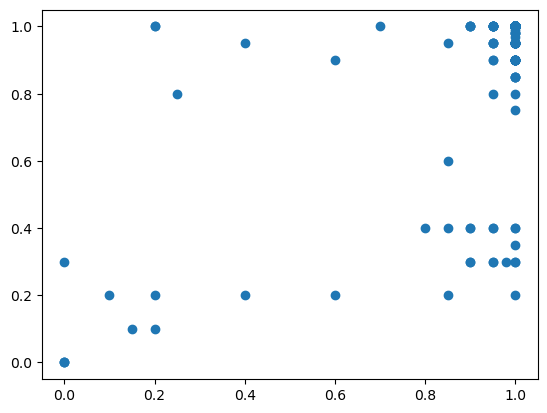

In [21]:
import matplotlib.pyplot as plt
plt.scatter(df["pro-score"].iloc[:300], df["flash-score"].iloc[:300])

In [22]:
df.to_csv("data_extension_abstracts.csv", index = False)